# Current version : 10.B (2025-07-23)

# Libraries and directory (always run)

In [1]:
### import necessary libraries
# import anndata as ad
from datetime import datetime

from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import geopandas as gpd
import random
import seaborn as sns
import scanpy as sc
from sklearn.neighbors import KNeighborsClassifier
import warnings

warnings.filterwarnings("ignore") 
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

pd.options.display.max_rows = 9999

start_time = datetime.now()

def print_with_elapsed_time(message):
    elapsed_time = datetime.now() - start_time
    elapsed_seconds = elapsed_time.total_seconds()
    print(f"[{elapsed_seconds:.2f} seconds] {message}")

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.15.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.10.6 pynndescent==0.5.13


In [2]:
# print(f"geopandas version: {gpd.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"scanpy version: {sc.__version__}")

pandas version: 2.2.3
scanpy version: 1.10.4


In [3]:
### Directory where the data is stored

# dir = "/mnt/d/Xenium" #Ubuntu
# dir = 'D:\\Xenium'
# dir = "/media/volume/data/spatial/hugo/data" #Ubuntu
# dir = "/media/volume/data/spatial/hugo/data/k5" #Ubuntu
# dir = '/media/volume/volume_spatial/hugo/data/test'
dir = '/media/volume/volume_spatial/hugo/data'

# dir_notebook = 'D:\\Jupyter_notebook/Xenium_jupyter_notebook'
# dir_notebook = '/mnt/d/Jupyter_notebook/Xenium_jupyter_notebook'
# dir_notebook = '/media/volume/data/spatial/hugo/notebook'
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'


In [4]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


# Data import

In [5]:
# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_clusters.h5ad.gz")
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz")


In [8]:
adata.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_counts',
       'batch', 'sample', 'mmc:class_name',
       'mmc:class_correlation_coefficient', 'mmc:subclass_name',
       'mmc:supertype_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'pct_counts_in_top_10_genes',
       'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_150_genes', 'run', 'leiden', 'cell_type_auto',
       'cell_class_auto', 'cell_type_newnum_auto', 'cell_class_newnum_auto',
       'cell_type_auto_sub', 'cell_type_newnum_auto_sub', 'cell_type_final',
       'cell_type_newnum_final', 'region_automap_name', 'region_automap_num',
       'cell_class', 'cell_class_newnum', 'circascore'

In [42]:
adata.obs[adata.obs['run']=="circa4"]['total_counts'].sum()

803425500.0

# Annotations

## Initial annotation

### Automatic initial annotation

In [ ]:
from module.subclustering_Xe import automatic_initial_annotation

adata = automatic_initial_annotation(adata, 'leiden')

## Cluster check

In [ ]:
# Generate new numbering base on unique 'cell type'

# all_cell_type = adata.obs['cell_type_auto'].unique()
# list_cell_nb = range(0, len(all_cell_type))
# mapping_dict = dict(zip(all_cell_type,list_cell_nb))
# adata.obs['cell_type_newnum_auto'] = adata.obs['cell_type_auto'].map(mapping_dict)
# mapping_dict

all_cell_type = adata.obs['cell_type_final'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['cell_type_newnum_final'] = adata.obs['cell_type_final'].map(mapping_dict)
mapping_dict


In [ ]:
# adata.obs.groupby('cell type')['cell type'].count()
adata.obs['cell_type_final'].value_counts().sort_index()

In [ ]:
### Check clusters one by one to see if they are present in all sample and which would need subclustering

# cluster_to_use = 'cell_type_newnum_auto'
# cluster_to_use = 'cell_type_newnum_auto_sub'
cluster_to_use = 'cell_type_newnum_final'
# cluster_to_use = 'mmc:subclass_num'
# cluster_to_use = 'mmc:class_num'
# cluster_to_use = 'region_automap_num'

### Generate a color palette for the clusters - to make color stay consistent across samples
adata.obs[cluster_to_use] = adata.obs[cluster_to_use].astype(str)

# Create a palette with a unique color for each cluster
num_clusters = len(adata.obs[cluster_to_use].astype(int).unique())
palette = sns.color_palette("tab20b", n_colors=num_clusters +1)

# Map each 'leiden' value to a color
adata.obs['leiden_colors'] = adata.obs[cluster_to_use].astype(int).apply(lambda x: palette[x])

# Map all cells
fig, axs = plt.subplots(4,3,figsize=(15, 15))
axs = axs.flatten()
clusters_plot = {"10":'black', ### For VLMC
    # '0': 'lightcoral', "1" : 'forestgreen', '2':'red', "3":'purple', "4":"yellow",
    # '5': 'lightcoral', "6" : 'forestgreen', "7":'red', "8":'purple', "9":"yellow",
    # '10': 'lightcoral',"11": 'forestgreen', '12':'red', "13":'purple', "14":"yellow", "15": "blue",
    # '16': 'lightcoral',"17": 'forestgreen', '18':'red', "19":'purple', "20":"yellow"
    # '21': 'lightcoral',"22": 'forestgreen', '23':'red', "":'purple', "":"yellow",
    # '24': 'lightcoral',"25": 'forestgreen', '26':'red', "27":'purple', "28":"yellow",
    # '29': 'lightcoral',"30": 'forestgreen', '31':'red', "32":'purple', "33":"yellow",
    # '34': 'lightcoral',"35": 'forestgreen', '36':'red', "37":'purple', "38":"yellow", "39": "blue",
    # '40': 'lightcoral',"41": 'forestgreen', '42':'red', "43":'purple', "44":"yellow", "45": "blue",
    # '46': 'lightcoral',"47": 'forestgreen', '48':'red', "49":'purple', "50":"orange", "51": "blue",
    # '52': 'lightcoral',"53": 'forestgreen', '54':'red', "55":'purple', "56":"yellow", "57": "blue",
    # '58': 'lightcoral',"59": 'forestgreen', '60':'red', "61":'purple', "62":"yellow", "63": "blue",
    # '64': 'lightcoral',"65": 'forestgreen', '66':'red', "67":'purple', "68":"yellow", "69": "blue",
    # '70': 'lightcoral',"71": 'forestgreen', '72':'red', "73":'purple', "74":"yellow", "75": "blue",
    # '76': 'lightcoral',"77": 'forestgreen', '78':'red', "79":'purple', "80":"yellow", "81": "blue",
    # '82': 'lightcoral',"83": 'forestgreen', '84':'red', "85":'purple', "86":"orange", "87": "blue",
    # '88': 'lightcoral',"89": 'forestgreen', '90':'red', "91":'purple', "92":"yellow", "93": "blue",
    # '94': 'lightcoral',"95": 'forestgreen', '96':'red', "97":'purple', "98":"yellow", "99": "blue",
    # '100':'lightcoral',"101": 'forestgreen', '102':'red', "103":'purple', "104":"yellow", "105": "blue",

    # '42': 'lightcoral',"43": 'forestgreen', '41':'red', "":'purple', "":"orange",'':'blue',
    '43': 'lightcoral',"": 'forestgreen', '':'red', "":'purple', "":"yellow",
}

for idx, sample in enumerate(samples_ids):
    adata_sel = adata[(adata.obs['sample'] == sample)]
    for cluster_id in adata_sel.obs[cluster_to_use].unique():
        cluster_data = adata_sel.obs[adata_sel.obs[cluster_to_use] == cluster_id]
        colors = clusters_plot[cluster_id] if cluster_id in clusters_plot else "none" ### for selected clusters in cluster_plot
        # colors = cluster_data['leiden_colors'].unique()[0] ### uncomment for all clusters
        axs[idx].scatter(cluster_data['x_centroid'], cluster_data['y_centroid'], color=colors, s=0.051, label=cluster_id)
        axs[idx].get_xaxis().set_visible(False)
        axs[idx].get_yaxis().set_visible(False)
        axs[idx].set_title(f"Sample {sample}")
del adata_sel

In [81]:
# To rename a cell type in case of typo or mistakes (easier than re-running)
rename_subclass = {
'L6 IT CTXGlut' : 'L6 IT CTX Glut'

}
                  
adata.obs['cell_type_final'] = adata.obs['cell_type_final'].apply(lambda x: rename_subclass[x] if x in rename_subclass else x)
adata.obs['cell_type_final'].unique()

array(['Astro TE', 'BST Glut', 'Vip Gaba', 'Sst Gaba', 'PVH Glut',
       'AHN Glut', 'LHA Glut', 'Oligodendrocyte', 'Endothelial',
       'MEA Glut', 'Ependymal', 'VLMC', 'SCH Gaba', 'ABC', 'Lamp5 Gaba',
       'STR PAL Gaba', 'L2 3 IT PIR ENTl Glut', 'CEA Gaba', 'LSX Gaba',
       'STR Gaba', 'STR D2 Gaba', 'L6b CTX Glut', 'L4 5 IT CTX Glut',
       'L6 IT CTX Glut', 'L5 ET CTX Glut', 'STR D1 Gaba', 'OPC',
       'NLOT Glut', 'SMC', 'Pvalb Gaba', 'COAa PAA MEA Glut', 'Choroid',
       'Pericyte', 'Microglia', 'CLA EPd CTX Glut', 'L6 CT CTX Glut',
       'PAL STR Gaba Chol', 'PVT Glut', 'PT Glut', 'RE Glut', 'SPA Glut',
       'OB STR CTX IMN', 'L5 NP CTX Glut', 'Sncg Gaba', 'RT ZI Gaba',
       'CA3 Glut', 'TRS BAC Glut', 'BAC Glut', 'DG PIR Ex IMN', 'DG Glut',
       'SMT Glut', 'AD Glut', 'AV Glut', 'CA2 FC IG Glut', 'Tanycyte',
       'MPO Glut', 'VM MD Glut', 'CM Glut', 'L2 3 IT RSP Glut', 'LD Glut',
       'LH Glut', 'MH Glut', 'VP Glut', 'CA1 ProS Glut'], dtype=object)

In [ ]:
adata.obsm['X_pca'] = adata.obsm['reduced_pc_20']
adata.obsm['X_umap'] = adata.obsm['reduced_pc_20_umap']

In [ ]:
if 'leiden_colors' in adata.obs:
    adata.obs = adata.obs.drop(columns=['leiden_colors'])

# adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_clusters.h5ad.gz", compression='gzip')
adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_clusters_combined.h5ad.gz", compression='gzip')

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_clusters_combined.h5ad.gz")

## Subclustering

In [ ]:
# adata.obs.groupby('cell type')['cell type'].count()
adata.obs['cell_type_final'].value_counts()

### Automatic subclustering

In [ ]:
from module.subclustering_Xe import auto_subclustering2

auto_subclustering2(adata_to_sub = adata, ###
                    all_types =  'all', ### 'all' or ['0','1'] for selected number of clusters
                    Clusters_to_use = 'cell_type_newnum_auto',
                    resolution = 0.2)

#### Table

In [ ]:
from module.subclustering_Xe import cluster_table

cont_tab, cont_tab_sub, cluster_df = cluster_table(adata_to_use = adata,
                                                   Clusters_to_use = 'cell_type_newnum_final',
                                                   sort_order='Cell Class',
                                                   sort_ascend = True
                                                
                                                   )

cluster_df

In [ ]:
tst_dict = cont_tab_sub.T.idxmax(axis=0).to_dict()
tst_dict = dict(zip(cluster_df.index, cluster_df['Celltype']))
tst_dict

#### Final clusters

In [ ]:
# Final clusters
rename_subclass = {0: 'Astro TE',
 3: 'Oligodendrocyte',
 17: 'L6 IT CTX Glut',
 14: 'STR D2 Gaba',
 4: 'Endothelial',
 16: 'L4 5 IT CTX Glut',
 28: 'Microglia',
 32: 'TH Glut',
 10: 'L2 3 IT PIR ENTl Glut',
 30: 'L6 CT CTX Glut',
 22: 'OPC',
 19: 'STR D1 Gaba',
 27: 'Pericyte',
 5: 'Ependymal',
 6: 'VLMC',
 25: 'Pvalb Gaba',
 8: 'ABC',
 1: 'Lamp5 Gaba',
 26: 'Choroid',
 2: 'Sst Gaba',
 18: 'L5 ET CTX Glut',
 9: 'STR PAL Gaba',
 49: 'DG Glut',
 38: 'TRS BAC Glut',
 15: 'L6b CTX Glut',
 7: 'SCH Gaba',
 37: 'LSX Gaba',
 21: 'COAa PAA MEA Glut',
 35: 'RT ZI Gaba',
 29: 'CLA EPd CTX Glut',
 11: 'CEA AAA BST Gaba',
 33: 'OB STR CTX IMN',
 48: 'MH Glut',
 34: 'L5 NP CTX Glut',
 36: 'CA3 Glut',
 50: 'CA1 ProS Glut',
 24: 'SMC',
 43: 'AV Glut',
 13: 'STR Gaba',
 45: 'CA2 FC IG Glut',
 31: 'PAL STR Gaba Chol',
 20: 'STR D1 Gaba',
 12: 'LSX Gaba',
 47: 'L2 3 IT RSP Glut',
 23: 'NLOT Glut',
 40: 'Microglia',
 46: 'Tanycyte',
 41: 'HPF CR Glut',
 44: 'LSX Gaba',
 39: 'DG PIR IMN',
 42: 'OB Gaba'}

adata.obs['cell_type_final'] = adata.obs['cell_type_newnum_auto_sub'].apply(lambda x: rename_subclass[x] if x in rename_subclass else x)
adata.obs['cell_type_final'].unique()

all_cell_type = adata.obs['cell_type_final'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['cell_type_newnum_final'] = adata.obs['cell_type_final'].map(mapping_dict)
mapping_dict

In [ ]:
### To rename only some cell types
rename_subclass = dict(zip(adata.obs['cell_type_newnum_final'],adata.obs['cell_type_final']))
rename_subclass_temp = {
43 : "OB STR CTX IMN",
41 : "DG Glut",
42 : 'DG Glut' 
}
rename_subclass.update(rename_subclass_temp)
adata.obs['cell_type_final'] = adata.obs['cell_type_newnum_final'].apply(lambda x: rename_subclass[x] if x in rename_subclass else x)
adata.obs['cell_type_final'].unique()

all_cell_type = adata.obs['cell_type_final'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['cell_type_newnum_final'] = adata.obs['cell_type_final'].map(mapping_dict)
mapping_dict

In [ ]:
### Correlation map
# Clusters_to_use = 'cell_type_newnum_auto_sub'
# cont_tab = pd.crosstab(adata_filter.obs[Clusters_to_use], adata_filter.obs['mmc:class_name'], normalize="index")
# cont_tab = cont_tab.loc[:, cont_tab.sum(axis=0) > 0.1] 
plt.figure(figsize=(40, 20))
sns.heatmap(cont_tab.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar = False)

In [ ]:
### Correlation map
# cont_tab_sub = pd.crosstab(adata_filter.obs[Clusters_to_use],adata_filter.obs['mmc:subclass_name'], normalize="index")
# cont_tab_sub = cont_tab_sub.loc[:, cont_tab_sub.sum(axis=0) > 0.05] 
plt.figure(figsize=(40, 50))
sns.heatmap(cont_tab_sub.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar = False)

In [ ]:
cont_tab_sub.T[2].sort_values(ascending=False).head(15)

### Manual subclustering

In [50]:
adata[adata.obs['cell_type_final']=='CA1 ProS Glut'].obs['sample'].value_counts()

sample
circa4-IGM-ZT13    1118
SD1-ZT09            852
circa4-IGM-ZT21     651
SD1-ZT05            545
SD1-ZT21              2
SD1-ZT01              1
SD1-ZT13              1
circa4-IGM-ZT17       1
Name: count, dtype: int64

In [52]:
# Clusters_to_use = 'cell_type_newnum_auto'
# Clusters_to_use = 'cell_type_newnum_auto_sub'
Clusters_to_use = 'cell_type_newnum_final'
# Clusters_to_use = 'cell_type_newnum'
# Clusters_to_use = 'leiden'
adata_filter = adata

<Axes: xlabel='cell_type_newnum_final', ylabel='mmc:subclass_name'>

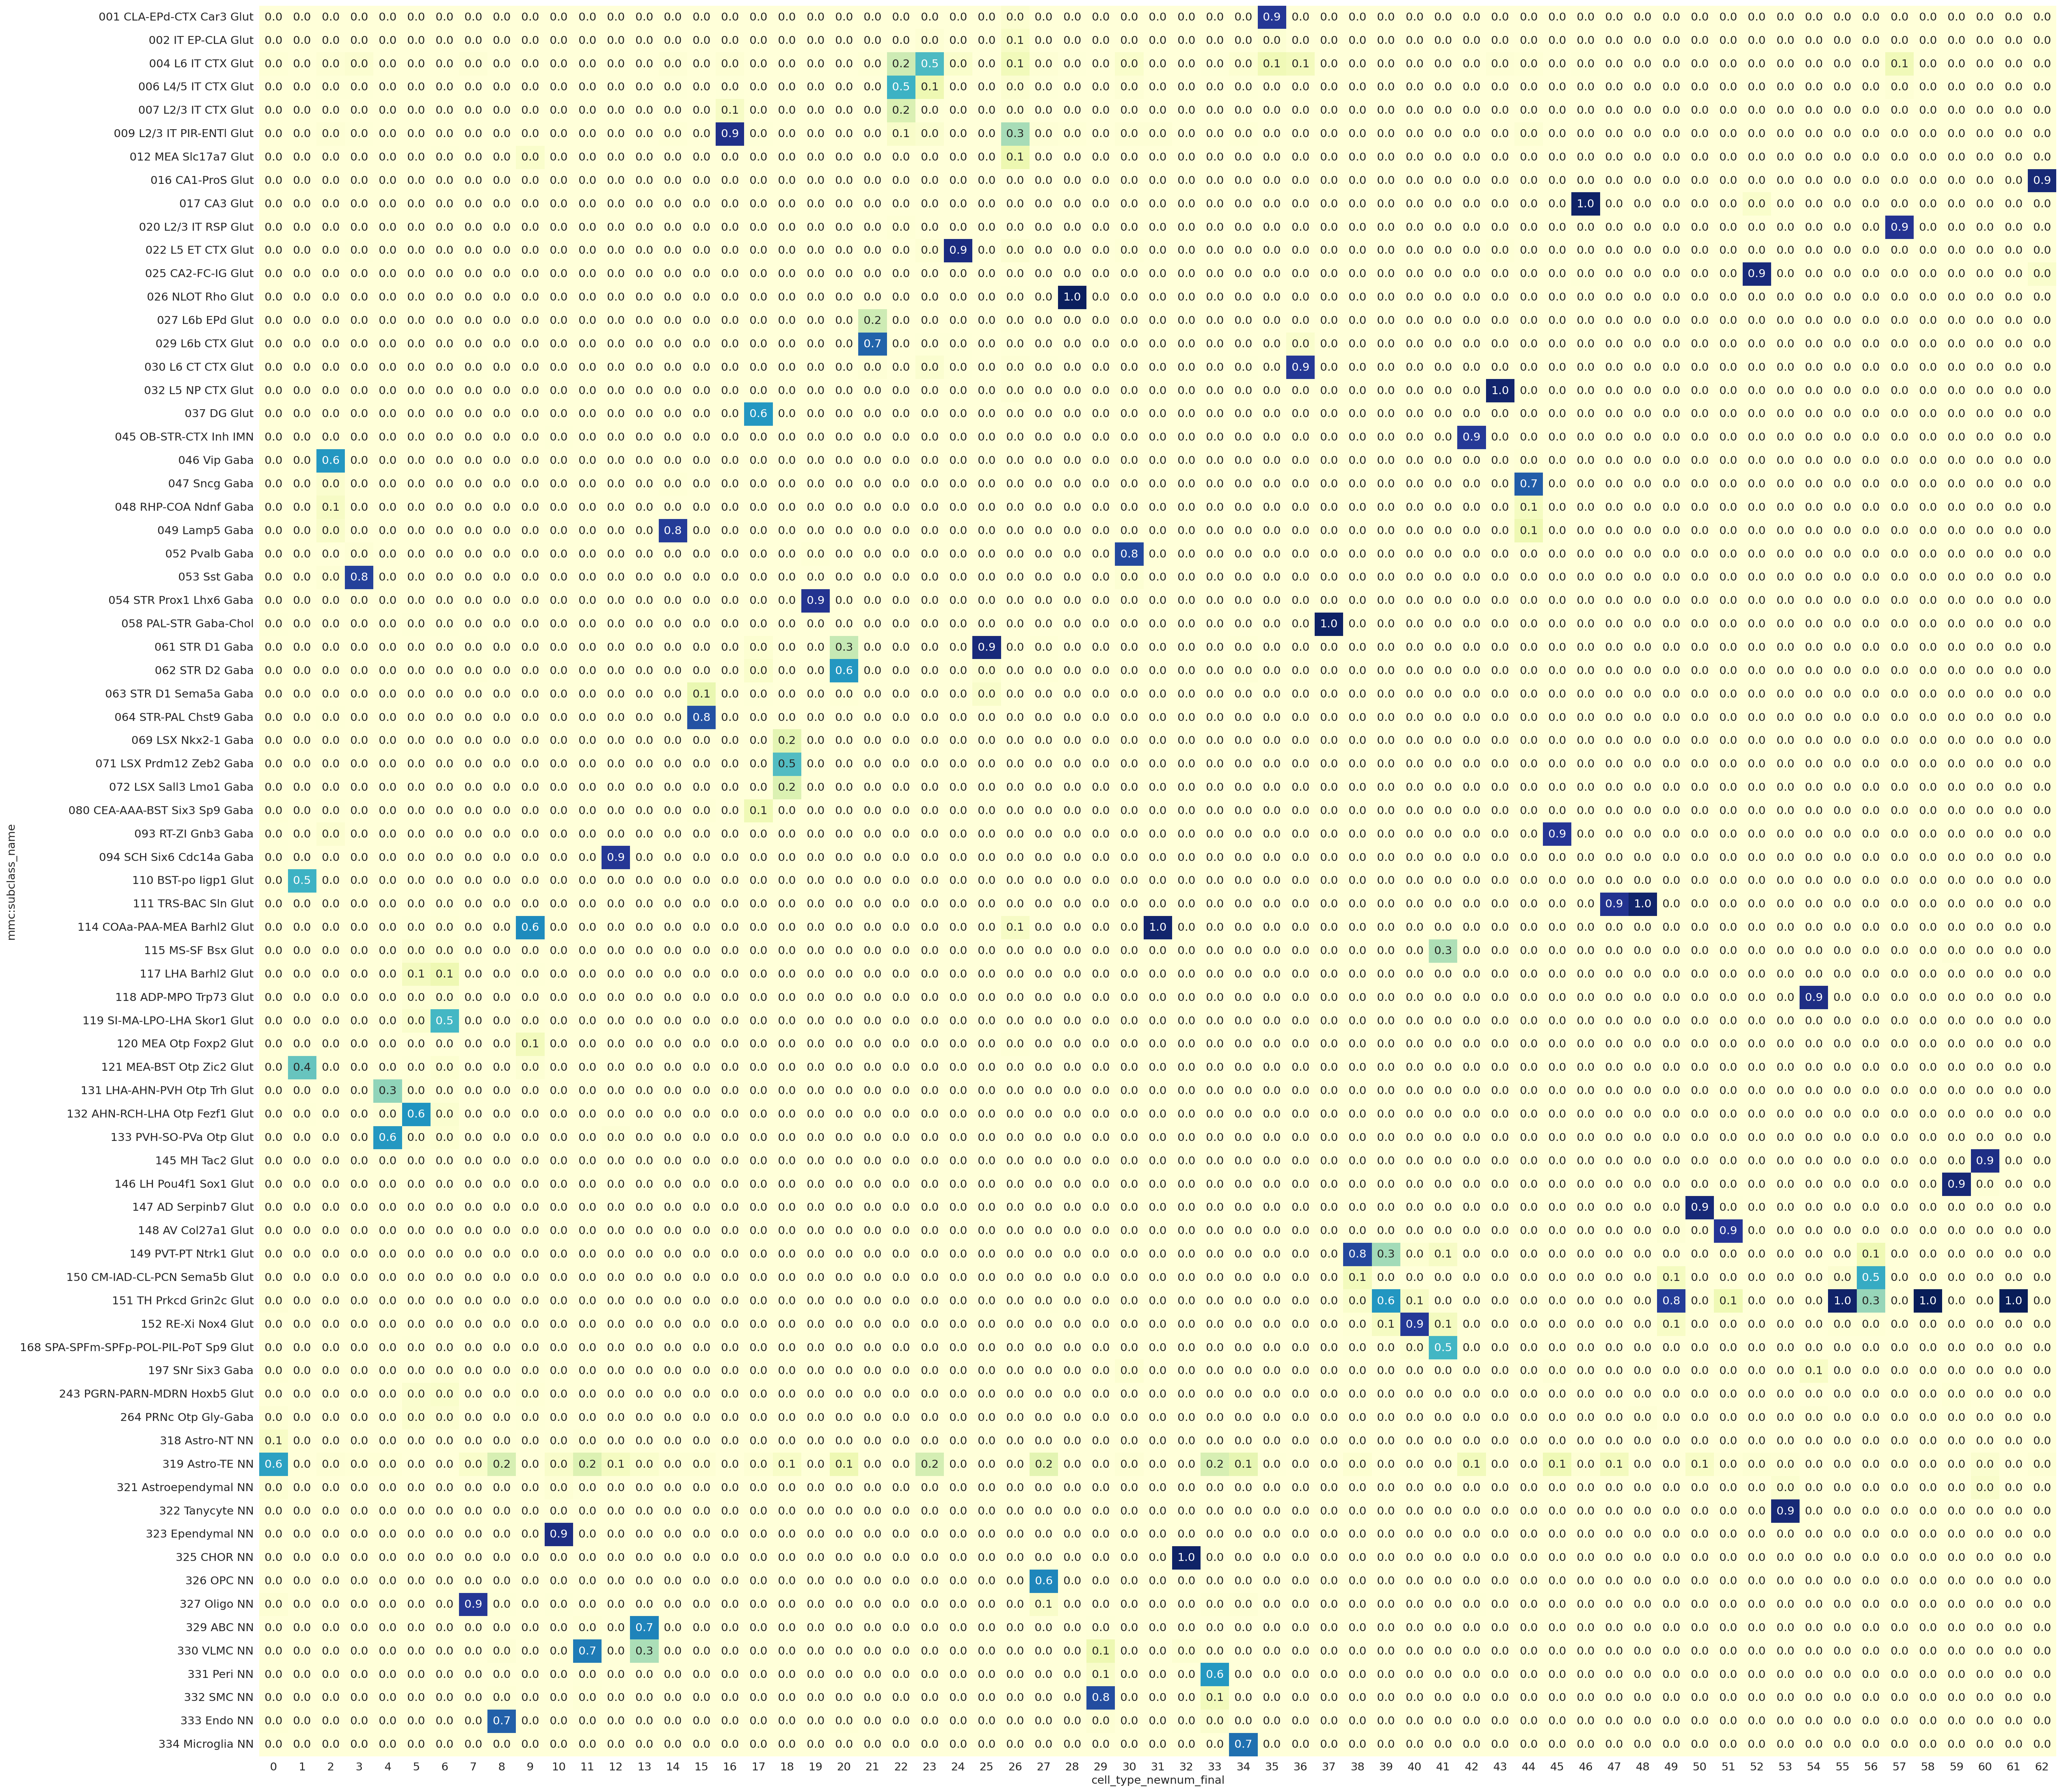

In [53]:
### Correlation map
cont_tab = pd.crosstab(adata_filter.obs[Clusters_to_use], adata_filter.obs['mmc:subclass_name'], normalize="index")
cont_tab = cont_tab.loc[:, cont_tab.sum(axis=0) > 0.1] 
plt.figure(figsize=(40, 40))
sns.heatmap(cont_tab.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar = False)

In [55]:
### Select a cluster to subcluster
cluster_to_sub = "26"


adata_subcluster = adata_filter[adata_filter.obs[Clusters_to_use] == cluster_to_sub]
adata_subcluster.obs[Clusters_to_use].sample() , adata_subcluster.shape

(circa4-IGM-ZT21_dggbpajh-1    26
 Name: cell_type_newnum_final, dtype: category
 Categories (1, object): ['26'],
 (5643, 5006))

In [56]:
sc.pp.pca(adata_subcluster)
sc.pp.neighbors(adata_subcluster)
sc.tl.umap(adata_subcluster)

In [57]:
# extract pca coordinates
X_pca = adata_subcluster.obsm['X_pca'] 

### Kmeans clustering
### You can choose the number of clusters by uncommenting n_clusters option
# kmeans = KMeans(#n_clusters=4,
#                 random_state=0).fit(X_pca) 
# adata_subcluster.obs['kmeans'] = kmeans.labels_.astype(str)

sc.tl.leiden(adata_subcluster, resolution = 0.4)

In [58]:
clustering_method = 'leiden'

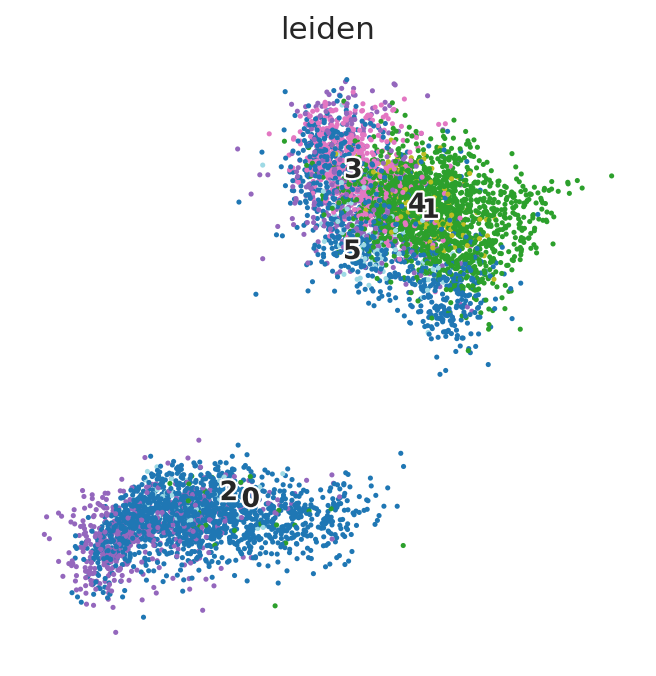

In [59]:
from matplotlib.pyplot import rc_context
with rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(
        adata_subcluster,
        color=clustering_method,
        add_outline=False,
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=False,
        palette="tab20",
    )
# sc.pl.pca(adata_subcluster,
#          color=clustering_method,
#          palette="tab20",
#          )

In [60]:
### Number of cells per clusters
max_clust = len(adata_subcluster.obs[clustering_method].unique())
for i in range(0, max_clust):
    count = adata_subcluster.obs[clustering_method].value_counts().iloc[i]
    print(f"Cluster {i} : {count} cells")

# adata_subcluster.obs['leiden'].sample(10)

Cluster 0 : 2332 cells
Cluster 1 : 1609 cells
Cluster 2 : 796 cells
Cluster 3 : 555 cells
Cluster 4 : 180 cells
Cluster 5 : 171 cells


<Axes: xlabel='leiden', ylabel='mmc:class_name'>

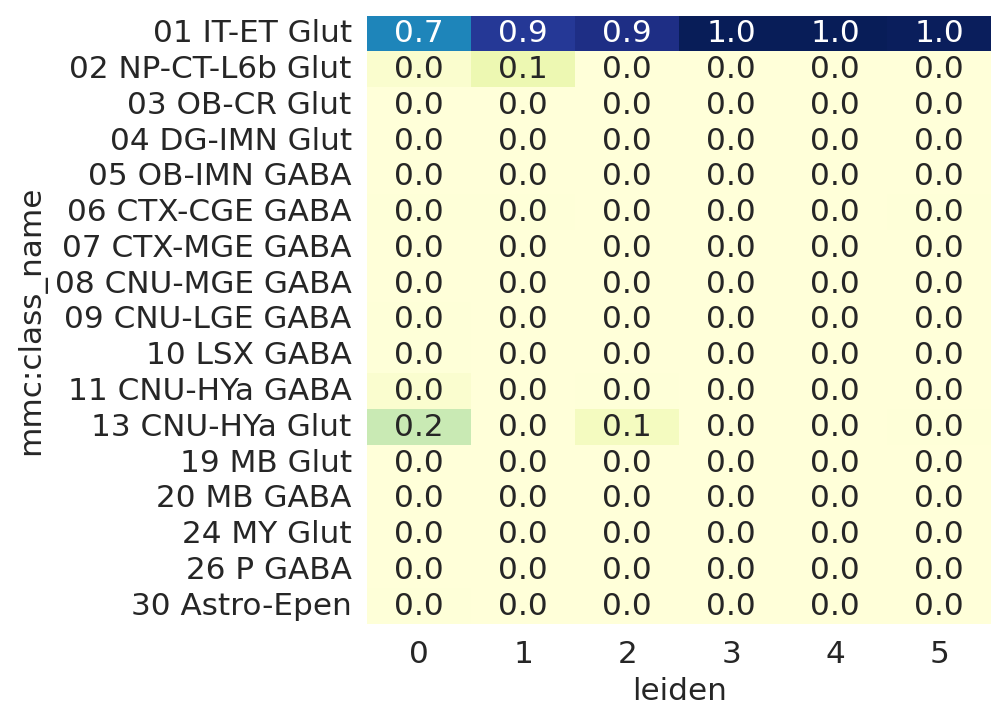

In [61]:
### Correlation map of subclusters
cont_tab = pd.crosstab(adata_subcluster.obs[clustering_method], adata_subcluster.obs['mmc:class_name'], normalize="index")
plt.figure(figsize=(5,5))
sns.heatmap(cont_tab.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar=False)

<Axes: xlabel='leiden', ylabel='mmc:subclass_name'>

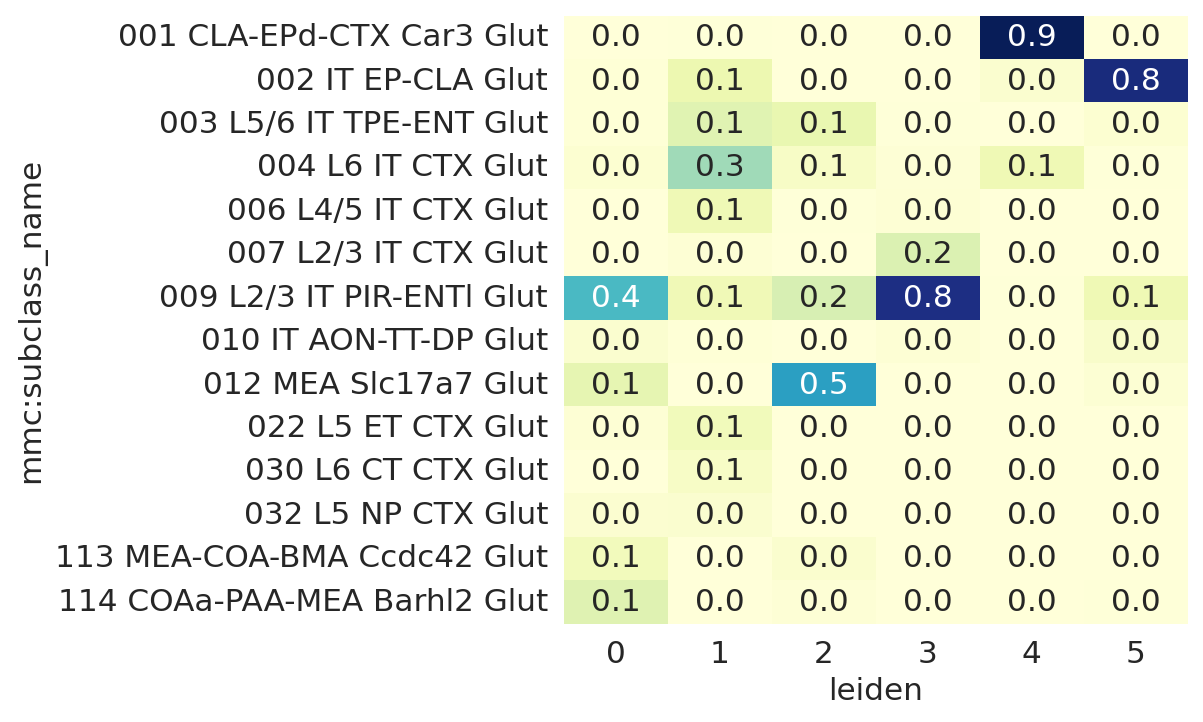

In [62]:
### Correlation map of subclusters
cont_tab = pd.crosstab(adata_subcluster.obs[clustering_method], adata_subcluster.obs['mmc:subclass_name'], normalize="index")
cont_tab = cont_tab.loc[:, cont_tab.sum(axis=0) > 0.05]
plt.figure(figsize=(5, 5))
sns.heatmap(cont_tab.T, annot=True, cmap="YlGnBu", fmt=".1f", cbar=False) 

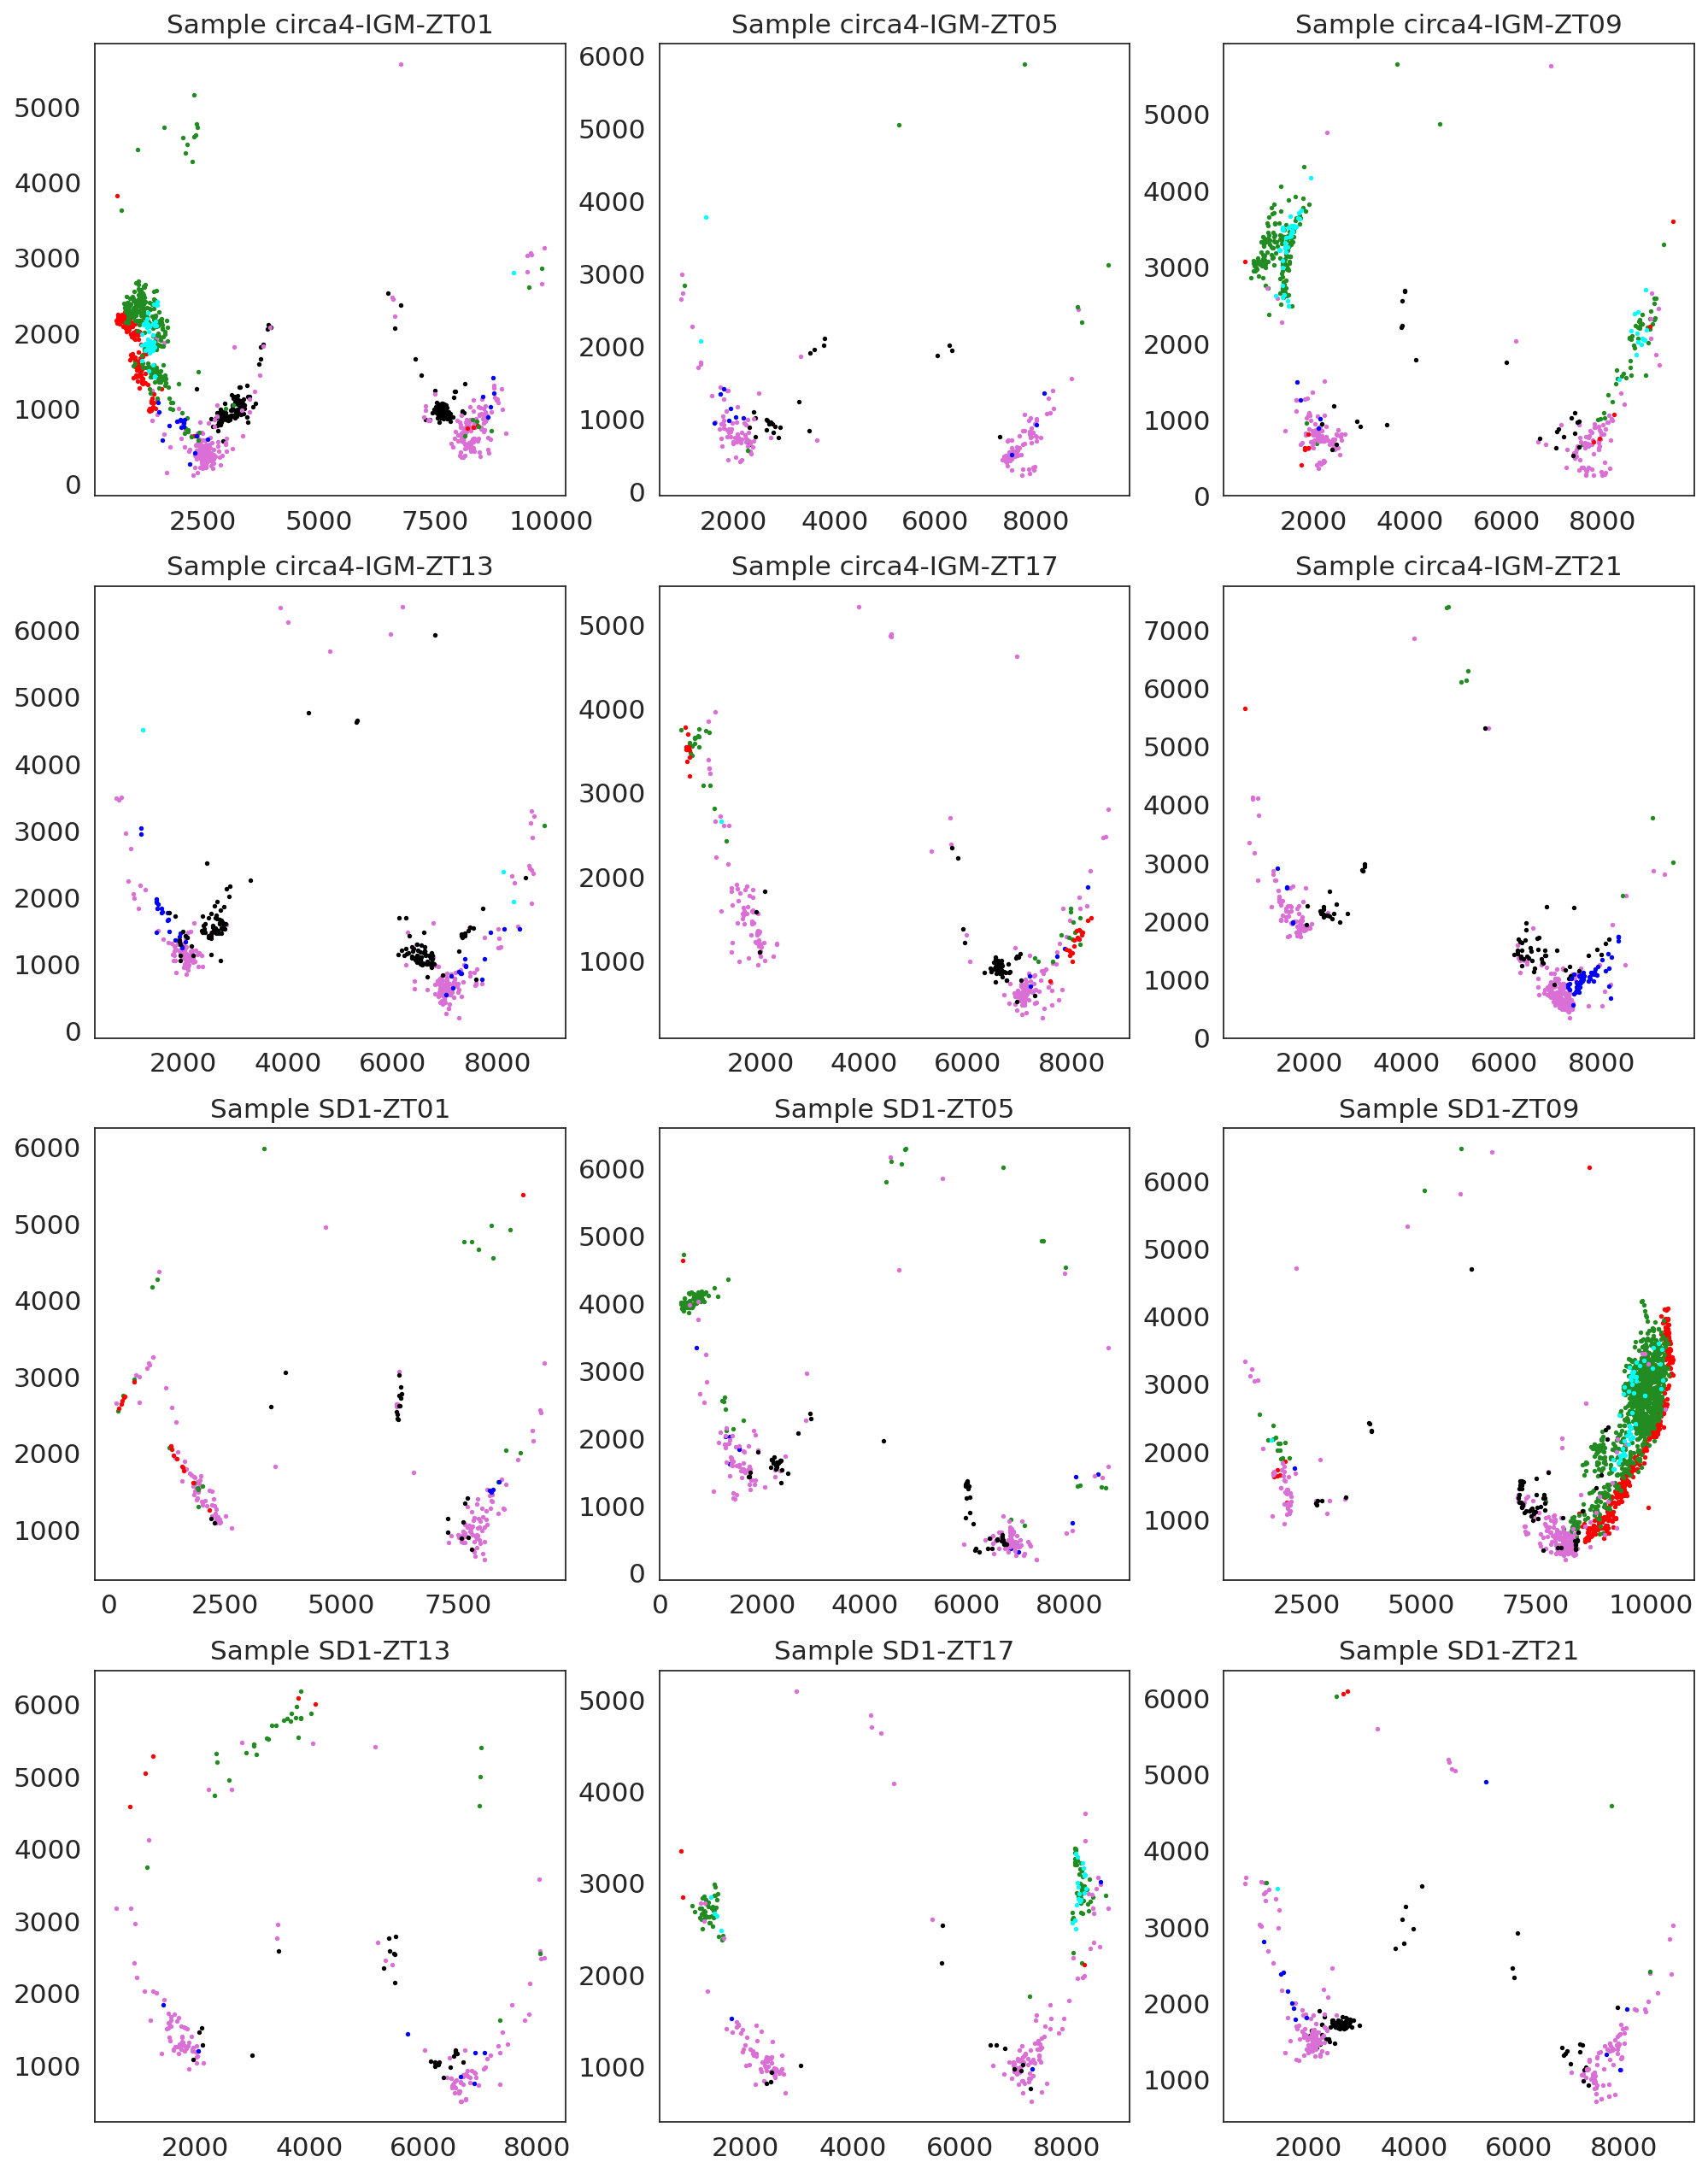

In [63]:
### Generate a color palette for the clusters - to make color stay consistent across samples
adata_subcluster.obs[clustering_method] = adata_subcluster.obs[clustering_method].astype(int)

# Create a palette with a unique color for each cluster
num_clusters = len(adata_subcluster.obs[clustering_method].unique())
palette = sns.color_palette("tab20", n_colors=num_clusters)

# Map each 'leiden' value to a color
adata_subcluster.obs['kmeans_colors'] = adata_subcluster.obs[clustering_method].apply(lambda x: palette[x])

# Mapping of clusters
fig, axs = plt.subplots(4,3,figsize=(15, 20))
axs = axs.flatten()
clusters_plot = {
    0: 'orchid', 1: 'forestgreen', 2: 'black', 3:'red', 4:'cyan', 5:'blue', 6:'darkorange',7:'coral',
    # 8:'forestgreen', 9: 'coral',10:'red', 11:'cyan',
    # 6:'blue',0:'darkorange', 14:'black'
}

for idx, sample in enumerate(samples_ids):
    adata_sel = adata_subcluster[(adata_subcluster.obs['sample'] == sample)]
    for cluster_id in adata_sel.obs[clustering_method].unique():
        cluster_data = adata_sel.obs[adata_sel.obs[clustering_method] == cluster_id]
        colors = clusters_plot[cluster_id] if cluster_id in clusters_plot else "none"
        # colors= cluster_data['kmeans_colors'].unique()[0]
        axs[idx].scatter(cluster_data['x_centroid'], cluster_data['y_centroid'], color=colors, s=2, label=cluster_id)
        axs[idx].set_title(f"Sample {sample}")

In [64]:
adata_subcluster.obs['new_cluster'] = clustering_method
adata_subcluster.obs['new_cluster2'] = adata_subcluster.obs[Clusters_to_use].astype("str") + '.' + adata_subcluster.obs[clustering_method].astype("str")
adata_subcluster.obs[['cell_id','new_cluster2']].sample(2)

,cell_id,new_cluster2
SD1-ZT09_khpfkfcf-1,SD1-ZT09_khpfkfcf-1,26.1
circa4-IGM-ZT21_dephadcc-1,circa4-IGM-ZT21_dephadcc-1,26.0


In [65]:
# Use this dictionnary to rename ['cell type'] with the new appropriate cell type for the subcluster. Follow the format. One subcluster at the time.
rename_subclass = {
 f'{cluster_to_sub}.0':'L2 3 IT PIR ENTl Glut',
f'{cluster_to_sub}.1':'L6 IT CTXGlut',
f'{cluster_to_sub}.2':'MEA Glut',
f'{cluster_to_sub}.3':'L2 3 IT PIR ENTl Glut',
f'{cluster_to_sub}.4':'CLA Glut',
f'{cluster_to_sub}.5':'CLA Glut',
f'{cluster_to_sub}.6':'',
f'{cluster_to_sub}.7':'',
f'{cluster_to_sub}.8' :'',
f'{cluster_to_sub}.9' :'',
f'{cluster_to_sub}.10':'',
f'{cluster_to_sub}.11':'',
f'{cluster_to_sub}.12':'',
f'{cluster_to_sub}.13':'',
f'{cluster_to_sub}.14':'',
f'{cluster_to_sub}.15':'',
f'{cluster_to_sub}.16':'',
f'{cluster_to_sub}.17':'',
}

adata_subcluster.obs['cell_type_final'] = adata_subcluster.obs['new_cluster2'].map(rename_subclass)

# Create a dictionary to map old values to new values
mapping_dict = dict(zip(adata_subcluster.obs['cell_id'], adata_subcluster.obs['cell_type_final']))

# Use .map() function to rename cell contents in 'col1' based on mapping dictionary
adata.obs['cell_type_final'] = adata.obs.apply(lambda x: mapping_dict[x['cell_id']] if x['cell_id'] in mapping_dict else x['cell_type_final'],axis = 1)

In [66]:
adata.obs["cell_type_final"].sample(5)


circa4-IGM-ZT17_hheiggie-1    Oligodendrocyte
circa4-IGM-ZT21_mjbllflh-1    Oligodendrocyte
SD1-ZT17_dkomekmd-1           Oligodendrocyte
SD1-ZT05_bglhpbgl-1               Endothelial
circa4-IGM-ZT21_nhodpcmm-1     L6 IT CTX Glut
Name: cell_type_final, dtype: object

In [ ]:
adata.obs['cell_type_final'].value_counts().sort_index()

In [ ]:
adata = adata[adata.obs['cell_type_final'] != 'Undefined']

<font size="6"><span style="color:red">From here, go back to process the other cluster if needed </span></font>

## File Save (and load)

In [82]:
all_cell_type = adata.obs['cell_type_final'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['cell_type_newnum_final'] = adata.obs['cell_type_final'].map(mapping_dict)
mapping_dict

{'Astro TE': 0,
 'BST Glut': 1,
 'Vip Gaba': 2,
 'Sst Gaba': 3,
 'PVH Glut': 4,
 'AHN Glut': 5,
 'LHA Glut': 6,
 'Oligodendrocyte': 7,
 'Endothelial': 8,
 'MEA Glut': 9,
 'Ependymal': 10,
 'VLMC': 11,
 'SCH Gaba': 12,
 'ABC': 13,
 'Lamp5 Gaba': 14,
 'STR PAL Gaba': 15,
 'L2 3 IT PIR ENTl Glut': 16,
 'CEA Gaba': 17,
 'LSX Gaba': 18,
 'STR Gaba': 19,
 'STR D2 Gaba': 20,
 'L6b CTX Glut': 21,
 'L4 5 IT CTX Glut': 22,
 'L6 IT CTX Glut': 23,
 'L5 ET CTX Glut': 24,
 'STR D1 Gaba': 25,
 'OPC': 26,
 'NLOT Glut': 27,
 'SMC': 28,
 'Pvalb Gaba': 29,
 'COAa PAA MEA Glut': 30,
 'Choroid': 31,
 'Pericyte': 32,
 'Microglia': 33,
 'CLA EPd CTX Glut': 34,
 'L6 CT CTX Glut': 35,
 'PAL STR Gaba Chol': 36,
 'PVT Glut': 37,
 'PT Glut': 38,
 'RE Glut': 39,
 'SPA Glut': 40,
 'OB STR CTX IMN': 41,
 'L5 NP CTX Glut': 42,
 'Sncg Gaba': 43,
 'RT ZI Gaba': 44,
 'CA3 Glut': 45,
 'TRS BAC Glut': 46,
 'BAC Glut': 47,
 'DG PIR Ex IMN': 48,
 'DG Glut': 49,
 'SMT Glut': 50,
 'AD Glut': 51,
 'AV Glut': 52,
 'CA2 FC IG Gl

In [78]:
adata.obs['cell_type_final'].value_counts().sort_index()

cell_type_final
ABC                       17315
AD Glut                     654
AHN Glut                  10449
AV Glut                    1928
Astro TE                 355773
BAC Glut                    691
BST Glut                   1861
CA1 ProS Glut              3171
CA2 FC IG Glut             2335
CA3 Glut                   4008
CEA Gaba                   5254
CLA EPd CTX Glut           6876
CM Glut                    3951
COAa PAA MEA Glut          3354
Choroid                   13442
DG Glut                    9736
DG PIR Ex IMN               497
Endothelial              102877
Ependymal                 25919
L2 3 IT PIR ENTl Glut     42150
L2 3 IT RSP Glut           1514
L4 5 IT CTX Glut          78069
L5 ET CTX Glut            10209
L5 NP CTX Glut             4057
L6 CT CTX Glut            38653
L6 IT CTX Glut           150861
L6 IT CTXGlut              1609
L6b CTX Glut               9448
LD Glut                    2577
LH Glut                    1004
LHA Glut                

In [83]:
if 'leiden_colors' in adata.obs:
    adata.obs = adata.obs.drop(columns=['leiden_colors'])

adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated_combined.h5ad.gz", compression='gzip')
adata.obs.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_MMC_Banksy_annotated_combined.parquet")

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated_combined.h5ad.gz")

In [71]:
adata.obs['cell_type_final'].nunique()

66

# Automap

## Data pre-processing

In [84]:
# testdf = pd.read_csv('Xenium-data-coordinates-CTX.csv')
testdf = pd.read_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_MMC_Banksy_annotated_combined.parquet")
testdf.shape

testdf = testdf.filter(['cell_id','run','sample','x_centroid','y_centroid','cell_type_final','cell_type_newnum_final'], axis=1)
### Only keep necessary columns

In [85]:
print(*testdf['cell_type_final'].unique(), sep='","')

Astro TE","BST Glut","Vip Gaba","Sst Gaba","PVH Glut","AHN Glut","LHA Glut","Oligodendrocyte","Endothelial","MEA Glut","Ependymal","VLMC","SCH Gaba","ABC","Lamp5 Gaba","STR PAL Gaba","L2 3 IT PIR ENTl Glut","CEA Gaba","LSX Gaba","STR Gaba","STR D2 Gaba","L6b CTX Glut","L4 5 IT CTX Glut","L6 IT CTX Glut","L5 ET CTX Glut","STR D1 Gaba","OPC","NLOT Glut","SMC","Pvalb Gaba","COAa PAA MEA Glut","Choroid","Pericyte","Microglia","CLA EPd CTX Glut","L6 CT CTX Glut","PAL STR Gaba Chol","PVT Glut","PT Glut","RE Glut","SPA Glut","OB STR CTX IMN","L5 NP CTX Glut","Sncg Gaba","RT ZI Gaba","CA3 Glut","TRS BAC Glut","BAC Glut","DG PIR Ex IMN","DG Glut","SMT Glut","AD Glut","AV Glut","CA2 FC IG Glut","Tanycyte","MPO Glut","VM MD Glut","CM Glut","L2 3 IT RSP Glut","LD Glut","LH Glut","MH Glut","VP Glut","CA1 ProS Glut


In [87]:
# Simplify names for mapping
rename_subclass = {
 'Oligo': 'Undefined',
 "Astro TE" : "Undefined",
 "Oligodendrocyte" : "Undefined",
 "Endothelial" : "Undefined",
 "Ependymal" : "Ependymal",
 "VLMC" : "VLMC",
 "ABC" : "Undefined",
 "OPC" : "Undefined",
 "Choroid" : "Choroid",
 "Pericyte" : "Undefined",
 "Microglia" : "Undefined",
 "SMC" : "Undefined",
 "Tanycyte" : "Tanycyte",

 "HY Glut" : "HY",

 "PVH Glut" : "PVH",
 "AHN Glut" : "AHN",
 "LHA Glut" : 'LHA',
 "BST Glut": 'BST',
 "PVT Glut" : 'PVT',
 "PT Glut" : 'PT',
 "RE Glut" : 'RE',
 "SPA Glut" : 'SPA',
 "SCH Gaba" : 'SCH',
 "LD Glut" : 'LD',
 "LH Glut" : 'LH',
 "MH Glut" : 'MH',
 "VP Glut" : 'VP',
 "BAC Glut" : 'BAC',
 "SMT Glut" : 'SMT',
 "AD Glut" : 'AD',
 "AV Glut" : 'AV',
 "MPO Glut" : 'MPO',
 "VM MD Glut" : "VM MD",
 "CM Glut" : "CM",
 "RT ZI Gaba" : "RT ZI",


 "Pvalb Gaba" : "CTX",
 "Lamp5 Gaba" : "CTX",
 "Sncg Gaba" : "CTX",
 "Vip Gaba" : "CTX",
 "Sst Gaba" : "CTX",

 "STR D1 Gaba" : "STR",
 "STR PAL Gaba" : "STR",
 "STR Gaba" : "STR",
 "STR D2 Gaba" : "STR",
 "PAL STR Gaba Chol" : "STR",

 "L6b CTX Glut" : "CTX",
 "L4 5 IT CTX Glut" : "CTX",
 "L6 IT CTX Glut" : "CTX",
 "L5 ET CTX Glut" : "CTX",
  "L2 3 IT RSP Glut" : "CTX",
 "L2 3 PIR ENTl Glut" : "CTX",
 "L5 NP CTX Glut" : "CTX",
 "L2 3 IT PIR ENTl Glut" : "CTX",
 "L6 CT CTX Glut" : "CTX",
 "NLOT Glut" : "CTX",


 "DG Glut" : "HIPP",
 "CA1 ProS Glut" : "HIPP",
 "CA2 FC IG Glut" : "HIPP",
 "CA3 Glut" : "HIPP",

 "LSX Gaba" : "LSX",
 "TRS BAC Glut" : "LSX",


 "MEA Glut" : "AMY",
 "COAa PAA MEA Glut" : "AMY",
 "CLA EPd CTX Glut" : "AMY",
 'CEA Gaba' :"AMY",
 
 "OB STR CTX IMN" : "Undefined",
 'DG PIR Ex IMN': "Undefined",
 "Undefinded" : "Undefined"
 }

testdf['cell_type_final'] = testdf['cell_type_final'].apply(lambda x: rename_subclass[x] if x in rename_subclass else x)
testdf = testdf[testdf['cell_type_final'] != 'Undefined']
testdf = testdf[testdf['cell_type_final'] != 'undefined']
testdf['cell_type_final'].unique()

array(['BST', 'CTX', 'PVH', 'AHN', 'LHA', 'AMY', 'Ependymal', 'VLMC',
       'SCH', 'STR', 'LSX', 'Choroid', 'PVT', 'PT', 'RE', 'SPA', 'RT ZI',
       'HIPP', 'BAC', 'SMT', 'AD', 'AV', 'Tanycyte', 'MPO', 'VM MD', 'CM',
       'LD', 'LH', 'MH', 'VP'], dtype=object)

In [88]:
sample_ids = testdf['sample'].unique()
sample_ids

['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', ..., 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']
Length: 12
Categories (12, object): ['SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', ..., 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21']

In [89]:
from module.automap import knn_mst_clustering
from module.automap import assign_chunk_labels
from module.automap import fill_any_chunks,fill_empty_chunks
from module.automap import grid_to_geojson_with_scaling
import json
from IPython.display import clear_output


count = 0
for sample_to_map in sample_ids:

    count +=1
    print(f'{datetime.now()}: automap of {sample_to_map} ({count}/{len(samples_ids)})')

    df = testdf[testdf['sample']==sample_to_map]
    all_cell_type = df['cell_type_final'].unique()
    list_cell_nb = range(0, len(all_cell_type))
    mapping_dict = dict(zip(all_cell_type,list_cell_nb))
    df['cell_type_newnum_final'] = df['cell_type_final'].map(mapping_dict)

    # Multiply centroid coordinates by 10 to convert to pixel coordinates
    df['x_pixel'] = df['x_centroid'] * 10
    df['y_pixel'] = df['y_centroid'] * 10

    ### Generate a color palette for the clusters - to make color stay consistent across samples
    df['cell_type_newnum_final'] = df['cell_type_newnum_final'].astype(str)

    ### Establish neighbors classifiers

    K = 10
    X = df[['x_pixel', 'y_pixel']].values
    y = df['cell_type_newnum_final'].astype(int).values
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X, y)
    df['knn_celltype'] = knn.predict(X)

    data = df
    valid_celltypes = data['knn_celltype'].value_counts()[data['knn_celltype'].value_counts() > 100].index
    data = data[data['knn_celltype'].isin(valid_celltypes)]
    unique_cell_types = sorted(data['knn_celltype'].unique())

    for cell_type in unique_cell_types:
        print(f"Processing cell type {cell_type}...")
        knn_mst_clustering(data, cell_type=cell_type, k=10)

    # Save the updated dataframe with cluster labels
    # data.to_csv('Xenium-data-coordinates-CTX-labeled.csv', index=False)
    print("Data with cluster labels saved.")

    data['knn_celltype'].value_counts()
    data['cluster_label'].isna().sum()

    # Get the value counts of each category
    value_counts = data['cluster_label'].value_counts()

    # Create a mapping based on the rank of value counts
    mapping_drg = {label: idx for idx, label in enumerate(value_counts.index, 1)}

    # Map the categorical strings to numbers based on the value counts
    data['cluster_label_numeric'] = data['cluster_label'].map(mapping_drg)
    data['cluster_label_numeric'].unique()
    data = data.dropna(subset=['cluster_label_numeric'])
    data['cluster_label_numeric'].isna().sum()

    ### Pixelize section and assign label
    chunk_size = 400  # Example chunk size
    threshold = 0.5  # Example threshold
    grid, x_bins, y_bins = assign_chunk_labels(data, chunk_size, threshold)


    filled_grid, x_bins, y_bins = fill_empty_chunks(grid, x_bins, y_bins, 4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 2)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 2)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,4)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,3)

    # Create the mapping as before
    mapping = data.groupby('knn_celltype')['cell_type_final'].agg(lambda x: x.value_counts().idxmax()).to_dict()

    # Create a new column 'knn_celltype_label' using the mapping
    data['knn_celltype_label'] = data['knn_celltype'].map(mapping)
    data['cell_type_newnum_final'] = data['cell_type_newnum_final'].astype(int)

    # Display the dataframe to verify
    display(data[['knn_celltype', 'knn_celltype_label']].sample(3))

    ### Export geojson
    value_counts = data[['knn_celltype', 'cell_type_final']].value_counts()
    value_counts_df = value_counts.reset_index(name='count')
    most_common_pairs = value_counts_df.groupby('knn_celltype').apply(lambda x: x.nlargest(1, 'count'))
    celltype_to_newnum = most_common_pairs.set_index('knn_celltype')['cell_type_final'].to_dict()
    celltype_to_newnum = {key + 1: value for key, value in celltype_to_newnum.items()}

    geojson_data = grid_to_geojson_with_scaling(filled_grid, x_bins, y_bins, celltype_to_newnum, scale_factor=10)
    clear_output()
    # Save the GeoJSON to a file
    with open(f'{dir_notebook}/coordinates/Region_prediction/Xenium-data-coordinates-filtered_{sample_to_map}.geojson', 'w') as f:
        json.dump(geojson_data, f, indent=2)


print(f'{datetime.now()}: automap done')




2025-08-08 00:54:48.804204: automap done


## Match cells with automatically generated regions

### Data pre-processing

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated_combined.h5ad.gz")

In [90]:
samples_ids = adata.obs['sample'].unique()
samples_ids

['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', ..., 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']
Length: 12
Categories (12, object): ['SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', ..., 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21']

In [91]:
count = 0
combine_dict = {}

for sample_to_map in samples_ids:
    count += 1
    print(f'{datetime.now()}: mapping of {sample_to_map} ({count}/{len(samples_ids)})')
    geojson  = gpd.read_file(f'{dir_notebook}/coordinates/Region_prediction/Xenium-data-coordinates-filtered_{sample_to_map}.geojson')
    geojson['geometry'][1]
    adata_sub = adata[adata.obs['sample'] == sample_to_map]

    ### Cell mapping
    centroid_gdp = gpd.GeoDataFrame(adata_sub.obs, geometry=gpd.points_from_xy(adata_sub.obs.x_centroid, adata_sub.obs.y_centroid))
    centroid_gdp.index.name = None
    centroid_gdp.crs = 'EPSG:4326'
    matched_cells = gpd.sjoin(centroid_gdp, geojson, predicate='within', how='left')

    mapping_dict_reg = dict(zip(matched_cells['cell_id'], matched_cells['cell_type_newnum_final_right']))
    adata_sub.obs['region_automap'] = adata_sub.obs['cell_id'].map(mapping_dict_reg)

    all_cell_type = adata_sub.obs['region_automap'].unique()
    list_cell_nb = range(0, len(all_cell_type))
    mapping_dict = dict(zip(all_cell_type,list_cell_nb))
    adata_sub.obs['region_automap_newnum'] = adata_sub.obs['region_automap'].map(mapping_dict)

    mapping_dict_reg = dict(zip(adata_sub.obs['cell_id'], adata_sub.obs['region_automap']))
    combine_dict.update(mapping_dict_reg)
    
print(f'{datetime.now()}: dict done')
adata.obs['region_automap_name'] = adata.obs['cell_id'].map(combine_dict)

if 'leiden_colors' in adata.obs:
    adata.obs = adata.obs.drop(columns=['leiden_colors'])

adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated_automap.h5ad.gz", compression = 'gzip')

# adata.obs.to_csv(f"{dir_notebook}/csv/{name_dir}/{name_dir}_MMC_Banksy_annotated_automap.csv.gz",
#          compression={'method': 'gzip'})


2025-08-08 00:56:31.419584: mapping of circa4-IGM-ZT01 (1/12)
2025-08-08 00:56:34.852668: mapping of circa4-IGM-ZT05 (2/12)
2025-08-08 00:56:36.626142: mapping of circa4-IGM-ZT09 (3/12)
2025-08-08 00:56:38.163897: mapping of circa4-IGM-ZT13 (4/12)
2025-08-08 00:56:40.635582: mapping of circa4-IGM-ZT17 (5/12)
2025-08-08 00:56:42.045205: mapping of circa4-IGM-ZT21 (6/12)
2025-08-08 00:56:43.889403: mapping of SD1-ZT01 (7/12)
2025-08-08 00:56:45.702648: mapping of SD1-ZT05 (8/12)
2025-08-08 00:56:48.240911: mapping of SD1-ZT09 (9/12)
2025-08-08 00:56:50.134535: mapping of SD1-ZT13 (10/12)
2025-08-08 00:56:51.665453: mapping of SD1-ZT17 (11/12)
2025-08-08 00:56:53.921398: mapping of SD1-ZT21 (12/12)
2025-08-08 00:56:55.310529: dict done


In [92]:
all_cell_type = adata.obs['region_automap_name'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['region_automap_num'] = adata.obs['region_automap_name'].map(mapping_dict)
mapping_dict

{'AMY': 0,
 'LHA': 1,
 'VLMC': 2,
 nan: 3,
 'AHN': 4,
 'SCH': 5,
 'Ependymal': 6,
 'PVH': 7,
 'STR': 8,
 'CTX': 9,
 'Choroid': 10,
 'BST': 11,
 'RE': 12,
 'PT': 13,
 'PVT': 14,
 'RT ZI': 15,
 'LSX': 16,
 'SMT': 17,
 'AV': 18,
 'Tanycyte': 19,
 'AD': 20,
 'CM': 21,
 'VM MD': 22,
 'MH': 23,
 'HIPP': 24,
 'VP': 25,
 'LD': 26,
 'LH': 27}

## Alternative Automap : WIP

In [ ]:
testdf = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

from module.xenium_preprocessing import add_annotations
testdf = add_annotations(adata,testdf)

# testdf = testdf.filter(['cell_id','sample','x_centroid','y_centroid','cell_type_final','cell_type_newnum_final','region_automap_name'], axis=1)
### Only keep necessary columns

In [ ]:
anno = 'x_centroid'
dict_temp = dict(zip(adata.obs['cell_id'], adata.obs[anno]))
testdf[anno] = testdf['cell_id'].map(dict_temp)
anno = 'y_centroid'
dict_temp = dict(zip(adata.obs['cell_id'], adata.obs[anno]))
testdf[anno] = testdf['cell_id'].map(dict_temp)

In [ ]:
testdf = testdf[testdf['region_automap_name']=='CTX']
testdf.sample()

In [ ]:
rename_subclass = {'Astro TE': 'Undefined',
 'Sst Gaba': 'Sst Gaba',
 'L2 3 IT PIR ENTl Glut': 'L2 3',
 'L6b CTX Glut': 'L6',
 'L4 5 IT CTX Glut': 'L4 5',
 'L6 IT CTX Glut': 'L6',
 'L5 ET CTX Glut': 'L5',
 'Pvalb Gaba': 'Pvalb Gaba',
 'Oligodendrocyte': 'Undefined',
 'DG Glut': 'Undefined',
 'COAa PAA MEA Glut': 'COA',
 'Lamp5 Gaba': 'Lamp5 Gaba',
 'Microglia': 'Undefined',
 'OPC': 'Undefined',
 'Pericyte': 'Undefined',
 'CLA EPd CTX Glut': 'CLA',
 'L6 CT CTX Glut': 'L6',
 'L2 3 PIR ENTl Glut': 'L2 3',
 'L5 NP CTX Glut': 'L5',
 'Sncg Gaba': 'Sncg Gaba',
 'Vip Gaba': 'Vip Gaba',
 'HY Glut': 'Undefined',
 'VLMC': 'Undefined',
 'ABC': 'Undefined',
 'Endothelial': 'Undefined',
 'STR PAL Gaba': 'Undefined',
 'STR D2 Gaba': 'Undefined',
 'OB STR CTX IMN': 'Undefined',
 'SMC': 'Undefined',
 'STR Gaba': 'Undefined',
 'PVT PT Glut': 'Undefined',
 'CA2 FC IG Glut': 'Undefined',
 'LSX Gaba': 'Undefined',
 'TRS BAC Glut': 'Undefined',
 'NLOT Glut': 'NLOT Glut',
 'STR D1 Gaba': 'Undefined',
 'PAL STR Gaba Chol': 'Undefined',
 'L2 3 IT RSP Glut': 'L2 3',
 'CA3 Glut': 'Undefined',
 'SCH Gaba': 'Undefined',
 'TH Glut': 'Undefined',
 'Ependymal': 'Undefined',
 'RT ZI Gaba': 'Undefined',
 'CA1 ProS Glut': 'Undefined',
 'Choroid': 'Undefined',
 'SUndefined':'Undefined'}

In [ ]:
testdf['cell_type_final'] = testdf['cell_type_final'].apply(lambda x: rename_subclass[x] if x in rename_subclass else x)
testdf = testdf[testdf['cell_type_final'] != 'Undefined']
testdf = testdf[testdf['cell_type_final'] != 'undefined']
testdf['cell_type_final'].unique()

In [ ]:
from module.automap import knn_mst_clustering
from module.automap import assign_chunk_labels
from module.automap import fill_any_chunks,fill_empty_chunks
from module.automap import grid_to_geojson_with_scaling
import json
from IPython.display import clear_output


count = 0
for sample_to_map in sample_ids:

    count +=1
    print(f'{datetime.now()}: automap of {sample_to_map} ({count}/{len(samples_ids)})')

    df = testdf[testdf['sample']==sample_to_map]
    all_cell_type = df['cell_type_final'].unique()
    list_cell_nb = range(0, len(all_cell_type))
    mapping_dict = dict(zip(all_cell_type,list_cell_nb))
    df['cell_type_newnum_final'] = df['cell_type_final'].map(mapping_dict)

    # Multiply centroid coordinates by 10 to convert to pixel coordinates
    df['x_pixel'] = df['x_centroid'] * 10
    df['y_pixel'] = df['y_centroid'] * 10

    ### Generate a color palette for the clusters - to make color stay consistent across samples
    df['cell_type_newnum_final'] = df['cell_type_newnum_final'].astype(str)

    ### Establish neighbors classifiers

    K = 10
    X = df[['x_pixel', 'y_pixel']].values
    y = df['cell_type_newnum_final'].astype(int).values
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X, y)
    df['knn_celltype'] = knn.predict(X)

    data = df
    valid_celltypes = data['knn_celltype'].value_counts()[data['knn_celltype'].value_counts() > 100].index
    data = data[data['knn_celltype'].isin(valid_celltypes)]
    unique_cell_types = sorted(data['knn_celltype'].unique())

    for cell_type in unique_cell_types:
        print(f"Processing cell type {cell_type}...")
        knn_mst_clustering(data, cell_type=cell_type, k=10)

    # Save the updated dataframe with cluster labels
    # data.to_csv('Xenium-data-coordinates-CTX-labeled.csv', index=False)
    print("Data with cluster labels saved.")

    data['knn_celltype'].value_counts()
    data['cluster_label'].isna().sum()

    # Get the value counts of each category
    value_counts = data['cluster_label'].value_counts()

    # Create a mapping based on the rank of value counts
    mapping_drg = {label: idx for idx, label in enumerate(value_counts.index, 1)}

    # Map the categorical strings to numbers based on the value counts
    data['cluster_label_numeric'] = data['cluster_label'].map(mapping_drg)
    data['cluster_label_numeric'].unique()
    data = data.dropna(subset=['cluster_label_numeric'])
    data['cluster_label_numeric'].isna().sum()

    ### Pixelize section and assign label
    chunk_size = 400  # Example chunk size
    threshold = 0.5  # Example threshold
    grid, x_bins, y_bins = assign_chunk_labels(data, chunk_size, threshold)


    filled_grid, x_bins, y_bins = fill_empty_chunks(grid, x_bins, y_bins, 4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,4)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 2)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 2)
    filled_grid, x_bins, y_bins = fill_empty_chunks(filled_grid, x_bins, y_bins, 3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,4)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,3)
    filled_grid, x_bins, y_bins = fill_any_chunks(filled_grid, x_bins, y_bins,3)

    # Create the mapping as before
    mapping = data.groupby('knn_celltype')['cell_type_final'].agg(lambda x: x.value_counts().idxmax()).to_dict()

    # Create a new column 'knn_celltype_label' using the mapping
    data['knn_celltype_label'] = data['knn_celltype'].map(mapping)
    data['cell_type_newnum_final'] = data['cell_type_newnum_final'].astype(int)

    # Display the dataframe to verify
    display(data[['knn_celltype', 'knn_celltype_label']].sample(3))

    ### Export geojson
    value_counts = data[['knn_celltype', 'cell_type_final']].value_counts()
    value_counts_df = value_counts.reset_index(name='count')
    most_common_pairs = value_counts_df.groupby('knn_celltype').apply(lambda x: x.nlargest(1, 'count'))
    celltype_to_newnum = most_common_pairs.set_index('knn_celltype')['cell_type_final'].to_dict()
    celltype_to_newnum = {key + 1: value for key, value in celltype_to_newnum.items()}

    geojson_data = grid_to_geojson_with_scaling(filled_grid, x_bins, y_bins, celltype_to_newnum, scale_factor=10)
    clear_output()
    # Save the GeoJSON to a file
    with open(f'{dir_notebook}/coordinates/Region_prediction/Xenium-data-coordinates-filtered_{sample_to_map}.geojson', 'w') as f:
        json.dump(geojson_data, f, indent=2)


print(f'{datetime.now()}: automap done')




In [ ]:
count = 0
combine_dict = {}

for sample_to_map in samples_ids:
    count += 1
    print(f'{datetime.now()}: mapping of {sample_to_map} ({count}/{len(samples_ids)})')
    geojson  = gpd.read_file(f'{dir_notebook}/coordinates/Region_prediction/Xenium-data-coordinates-filtered_{sample_to_map}.geojson')
    geojson['geometry'][1]
    adata_sub = adata[adata.obs['sample'] == sample_to_map]

    ### Cell mapping
    centroid_gdp = gpd.GeoDataFrame(adata_sub.obs, geometry=gpd.points_from_xy(adata_sub.obs.x_centroid, adata_sub.obs.y_centroid))
    centroid_gdp.index.name = None
    centroid_gdp.crs = 'EPSG:4326'
    matched_cells = gpd.sjoin(centroid_gdp, geojson, predicate='within', how='left')

    mapping_dict_reg = dict(zip(matched_cells['cell_id'], matched_cells['cell_type_newnum_final_right']))
    adata_sub.obs['region_automap'] = adata_sub.obs['cell_id'].map(mapping_dict_reg)

    all_cell_type = adata_sub.obs['region_automap'].unique()
    list_cell_nb = range(0, len(all_cell_type))
    mapping_dict = dict(zip(all_cell_type,list_cell_nb))
    adata_sub.obs['region_automap_newnum'] = adata_sub.obs['region_automap'].map(mapping_dict)

    mapping_dict_reg = dict(zip(adata_sub.obs['cell_id'], adata_sub.obs['region_automap']))
    combine_dict.update(mapping_dict_reg)
    
print(f'{datetime.now()}: dict done')
adata.obs['region_automap_CTX_name'] = adata.obs['cell_id'].map(combine_dict)

# Manual Map

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_MMC_Banksy_annotated_automap.h5ad.gz") 
# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz") 

In [ ]:
sample_ids = adata.obs['sample'].unique()
sample_ids = sample_ids[0:6]
sample_ids

In [ ]:
### Choose sample to map here:
sample_to_map = sample_ids[0]
sample_to_map
BR_df = pd.read_csv(f"coordinates/XE_selection/{sample_to_map}-RL.csv",comment = '#')

In [ ]:
#Preprocessing the coordinates from Xenium Explorer into usable geojson

for sample_to_map in sample_ids:
    BR_df = pd.read_csv(f"coordinates/XE_selection/{sample_to_map}-RL.csv",comment = '#')
    # Group the dataframe by the "Selection" column
    grouped = BR_df.groupby('Selection')

    # List to hold GeoJSON features
    features = []

    for name, group in grouped:
        # Create a list of coordinates for each region
        coordinates = [(x, y) for x, y in zip(group['X'], group['Y'])]
        if coordinates[0] != coordinates[-1]:
            coordinates.append(coordinates[0])
        
        # Create a GeoJSON polygon for the region
        polygon = geojson.Polygon([coordinates])
        feature = geojson.Feature(geometry=polygon, properties={"region": name})
        features.append(feature)

    # Create a GeoJSON FeatureCollection
    feature_collection = geojson.FeatureCollection(features)

    # Save the GeoJSON FeatureCollection to a file
    with open(f'coordinates/{sample_to_map}_regions_manual.geojson', 'w') as f:
        geojson.dump(feature_collection, f)

    print(f"GeoJSON {sample_to_map} saved")

In [ ]:
for sample_to_map in sample_ids[0:6]:
    regions_df = gpd.read_file(f'{dir_notebook}/coordinates/{sample_to_map}_regions_manual.geojson')
    #Region mapping
    adata_region_sub = adata[adata.obs['sample']== sample_to_map]

    centroid_gdp = gpd.GeoDataFrame(adata_region_sub.obs, geometry=gpd.points_from_xy(adata_region_sub.obs.x_centroid, adata_region_sub.obs.y_centroid))
    centroid_gdp.index.name = None
    centroid_gdp.crs = 'EPSG:4326'
    matched_cells = gpd.sjoin(centroid_gdp, regions_df, predicate='within', how='left')
    mapping_dict_reg = dict(zip(matched_cells['cell_id'], matched_cells['region']))
    adata_region_sub.obs['region_manual'] = adata_region_sub.obs['cell_id'].map(mapping_dict_reg)

    all_cell_type = adata_region_sub.obs['region_manual'].unique()
    list_cell_nb = range(0, len(all_cell_type))
    mapping_dict = dict(zip(all_cell_type,list_cell_nb))
    adata_region_sub.obs['region_manual_newnum'] = adata_region_sub.obs['region_manual'].map(mapping_dict)
    mapping_dict_reg = dict(zip(adata_region_sub.obs['cell_id'], adata_region_sub.obs['region_manual']))

    if 'combine_dict_region' not in locals():
        combine_dict_region = {}
        combine_dict_region.update(mapping_dict_reg)   
    else:
        combine_dict_region.update(mapping_dict_reg)


<font size="6"><span style="color:red">From here, go back to process the other samples </span></font>

## Apply combined dictionnary

In [ ]:
### Only run when you are done with all samples automap annotations
adata.obs['region_manual_name'] = adata.obs['cell_id'].map(combine_dict_region)

In [ ]:
adata.obs['region_manual_name'].value_counts()

# Optional annotations

## Type of cells (VENG)

In [93]:
from module.subclustering_Xe import cell_class_annotation

adata = cell_class_annotation(adata)


all_cell_type = adata.obs['cell_class'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['cell_class_newnum'] = adata.obs['cell_class'].map(mapping_dict)
mapping_dict

adata.obs['cell_class'].value_counts()
# adata.obs[adata.obs['cell_class'] == 'Epithelial']['cell_type_final'].value_counts(dropna=True)

cell_class
Neuronal     694423
Glial        686820
Vascular     171653
Ependymal     39792
Name: count, dtype: int64

In [94]:
### To add White matter annotation to unlabeled cell region
### Not sure which solution work... to test later

temp = adata.obs['region_automap_name'].cat.add_categories("WM").fillna("WM")
adata.obs['region_automap_name'] = temp
all_cell_type = adata.obs['region_automap_name'].unique()
list_cell_nb = range(0, len(all_cell_type))
mapping_dict = dict(zip(all_cell_type,list_cell_nb))
adata.obs['region_automap_num'] = adata.obs['region_automap_name'].map(mapping_dict)
mapping_dict

{'AMY': 0,
 'LHA': 1,
 'VLMC': 2,
 'WM': 3,
 'AHN': 4,
 'SCH': 5,
 'Ependymal': 6,
 'PVH': 7,
 'STR': 8,
 'CTX': 9,
 'Choroid': 10,
 'BST': 11,
 'RE': 12,
 'PT': 13,
 'PVT': 14,
 'RT ZI': 15,
 'LSX': 16,
 'SMT': 17,
 'AV': 18,
 'Tanycyte': 19,
 'AD': 20,
 'CM': 21,
 'VM MD': 22,
 'MH': 23,
 'HIPP': 24,
 'VP': 25,
 'LD': 26,
 'LH': 27}

## Neurotransmitter

In [95]:
dict_neurotrans = {}

for cell in adata.obs['cell_type_final'].unique():
    if cell.split(' ')[-1] == 'Gaba':
        dict_neurotrans[cell] = 'Gaba'
    elif cell.split(' ')[-1] == 'Glut':
        dict_neurotrans[cell] = 'Glutamate'
    elif cell.split(' ')[-1] == 'Chol':
        dict_neurotrans[cell] = 'Acetylcholine'
    elif cell.split(' ')[-1] == 'Dopa':
        dict_neurotrans[cell] = 'Dopamine'
    else:
        dict_neurotrans[cell] = 'Non-neuronal'

In [96]:
adata.obs['Neurotransmitter'] = adata.obs['cell_type_final'].map(dict_neurotrans)
adata.obs['Neurotransmitter'].value_counts()

Neurotransmitter
Non-neuronal     903963
Glutamate        446176
Gaba             240478
Acetylcholine      2071
Name: count, dtype: int64

## Circascore

In [97]:
from module.subclustering_Xe import circascore_annot

df = pd.read_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_normalized_counts.parquet")

adata = circascore_annot(adata,df)

In [ ]:
adata.obs.groupby('run')['circascore'].value_counts()

## ZT

In [98]:
### If ZT is in the sample name
adata.obs['ZT'] = adata.obs['sample'].map(lambda name: name.split('-')[-1])

In [ ]:
### Other case
ZT_dict = {
    '3159-1':'ZT17','2670-1':'ZT5','3159-2':'ZT17','3159-3':'ZT17','3159-4':'ZT17','2505-1':'ZT5','2505-2':'ZT5',
'3160-1':'ZT17','3160-2':'ZT17','3161-1':'ZT17','3161-2':'ZT17','3161-3':'ZT17',
}
adata.obs['ZT'] = adata.obs['sample'].map(ZT_dict)

In [ ]:
adata.obs['ZT'].value_counts()

## Genotype

In [ ]:
geno_dict = {'3159-1':'WT','2670-1':'WT','3159-2':'WT','3159-3':'WT','3159-4':'WT',
             '2505-1':'APP','2505-2':'APP','3160-1':'APP','3160-2':'APP','3161-1':'APP','3161-2':'APP','3161-3':'APP',
}

adata.obs['Genotype'] = adata.obs['sample'].map(geno_dict)

# Final Output

In [99]:
if 'leiden_colors' in adata.obs:
    adata.obs = adata.obs.drop(columns=['leiden_colors'])

adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz", compression = 'gzip')

# adata.obs.to_csv(f"{dir_notebook}/csv/{name_dir}/{name_dir}_MMC_Banksy_annotated_automap.csv.gz",
#          compression={'method': 'gzip'})

In [6]:
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet")

In [7]:
df_NS = df[df['run']=='circa4']
df_SD = df[df['run']=='SD1']

df_NS.to_parquet(f"{dir_notebook}/csv/{name_dir}/circa4_norm_combined.parquet")
df_SD.to_parquet(f"{dir_notebook}/csv/{name_dir}/SD1_norm_combined.parquet")

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz")

# End of the notebook

Next step : Data vizualization and analysis

[v10C_DataViz_Analysis](./v10C_DataViz_Analysis.ipynb)